In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

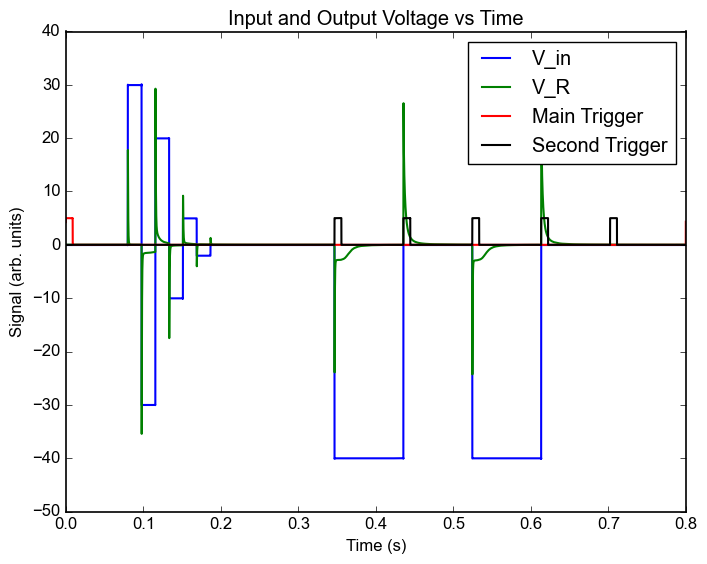

In [32]:
data1 = np.loadtxt("./Data_20262904/20262904005.dat")
data2 = np.loadtxt("./Data_20262904/20262904005.snp")

R1 = 1e6
R2 = 1e5  # Resistance in ohms
Amp = -20

t = data1[:, 0]
V_R = data1[:, 1]
main_trigger = data1[:, 2]
V_in = data1[:, 3]*Amp
second_trigger = data1[:, 4]
I = data1[:, 5]


plt.plot(t, V_in, label='V_in', lw = 1.5, color = 'blue')
plt.plot(t, V_R*10, label='V_R', lw = 1.5, color = 'green')
plt.plot(t, main_trigger, label='Main Trigger', lw = 1.5, color = 'red')
plt.plot(t, second_trigger, label='Second Trigger', lw = 1.5, color = 'black')
plt.xlabel('Time (s)')
plt.ylabel('Signal (arb. units)')
# plt.xlim(0.02, 0.22)

plt.title('Input and Output Voltage vs Time')
plt.legend()
plt.show()


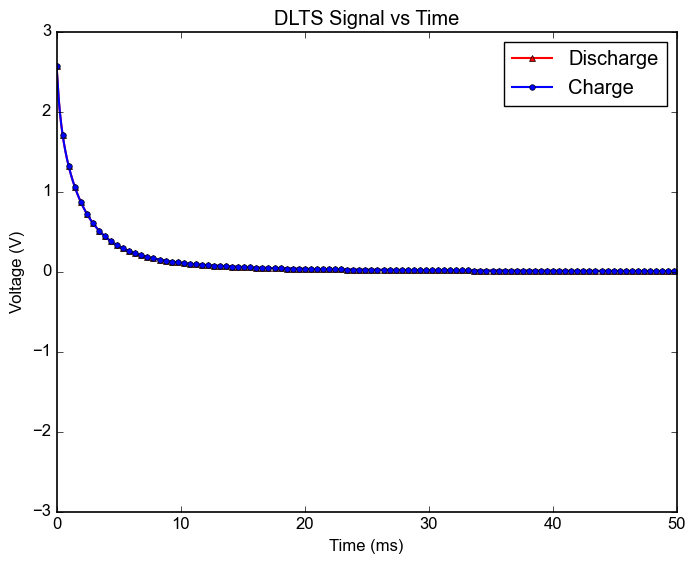

In [33]:
t = data2[:, 0]
V = data2[:, 2]
V2 = data2[:, 2]

plt.plot(t*1e3, V, label='Discharge', color='red', ls='-', lw = 1.5, marker='^', markersize=4, markevery=50)
plt.plot(t*1e3, V2, label='Charge', color='blue', ls='-', lw = 1.5, marker='o', markersize=4, markevery=50)
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')
plt.title('DLTS Signal vs Time')
plt.xlim(0.00, 50)
plt.ylim(-3, 3)
plt.legend(frameon=True, numpoints=1)
plt.show()


a = 2.09 ± 0.00464
b = 0.00236 ± 7.83e-06
c = 0.0285 ± 0.000561
R^2 = 0.986
-----------------------------
C (fitted) = (2.170 ± 0.007) nF
R_L (fitted) = (80.747 ± 1.602) MΩ
Leakage current I_L = 309.608 nA


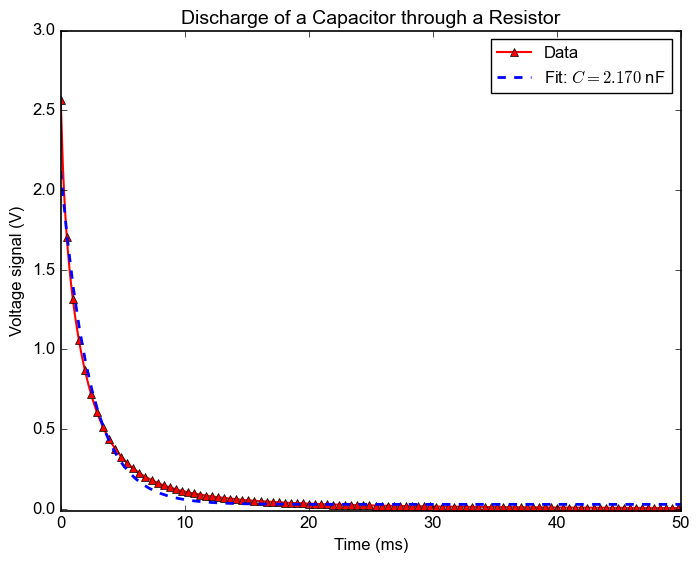

In [34]:
def func(x, a, b, c):
    return a * np.exp(-x / b) + c


mask = np.isfinite(t) & np.isfinite(V) & (t >= 0.00) & (t <= 0.05)
# Initial guesses: a ~ peak voltage in window, b ~ C_actual*(R1+R2) (time constant)
if np.any(mask):
    a0 = np.max(V[mask])
else:
    a0 = np.max(V)
C_actual = 3e-9  # 10 nF
b0 = C_actual * (R1 + R2)
c0 = np.min(V[mask])
p0 = [a0, b0, c0]

popt, pcov = curve_fit(func, t[mask], V[mask], p0=p0, maxfev=10000)
sigma_fit = func(t[mask], *popt)
a, b, c = popt

# Coefficient of determination
ss_res = np.sum((V[mask] - sigma_fit) ** 2)
ss_tot = np.sum((V[mask] - np.mean(V[mask])) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err, c_err = perr

R_L = a/c*(R1 + R2)
R_L_err = R_L * np.sqrt((a_err/a)**2 + (c_err/c)**2)
C = b / (1/(R1 + R2) + 1/R_L)**(-1)
C_err = b_err / (1/(R1 + R2) + 1/R_L)**(-1)

print(f"a = {a:.3g} ± {a_err:.3g}")
print(f"b = {b:.3g} ± {b_err:.3g}")
print(f"c = {c:.3g} ± {c_err:.3g}")
print(f"R^2 = {r2:.3f}")
print("-----------------------------")
print(f"C (fitted) = ({C*1e9:.3f} ± {C_err*1e9:.3f}) nF")
print(f"R_L (fitted) = ({R_L/1e6:.3f} ± {R_L_err/1e6:.3f}) MΩ")

V_T = 5
I_L = (30 - V_T) / R_L
print(f"Leakage current I_L = {I_L*1e9:.3f} nA")


x = np.linspace(0.00, 0.05, 100)
plt.plot(t*1e3, V, '^', label='Data', color='red', markersize=6, ls='-', lw = 1.5, markevery=50)
plt.plot(x*1e3, func(x, *popt), lw=2, label=rf'Fit: $C={C*1e9:.3f}$ nF', color='blue', linestyle='--')
plt.xlabel(r"Time (ms)")
plt.ylabel(r"Voltage signal (V)")
plt.xlim(0.00, 50)
plt.ylim(-0.01, 3)
plt.legend(frameon=True, loc='upper right', numpoints=1, fontsize=12)
plt.title("Discharge of a Capacitor through a Resistor", fontsize=14)
# plt.savefig("conductance_PS9.eps", format='eps', bbox_inches='tight')
plt.show()

C:\Users\lugwi\AppData\Local\Temp\ipykernel_18868\2609870272.py:5: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.xlim(0.00, 90)
C:\Users\lugwi\AppData\Local\Temp\ipykernel_18868\2609870272.py:6: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 3)


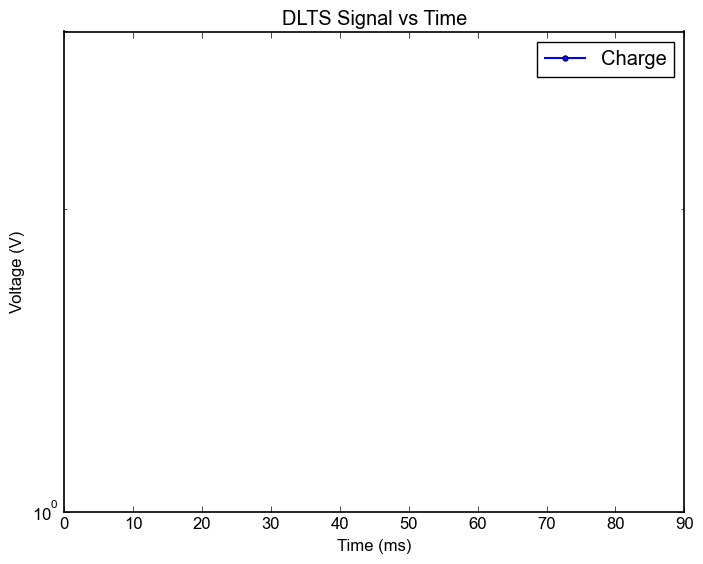

In [35]:

plt.semilogy(t*1e3, -V2, label='Charge', color='blue', ls='-', lw = 1.5, marker='o', markersize=4, markevery=50)
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')
plt.title('DLTS Signal vs Time')
plt.xlim(0.00, 90)
plt.ylim(0, 3)
plt.legend(frameon=True, numpoints=1)
plt.show()

a1 = 1.52 ± 0.00472
b1 = 0.00111 ± 4.87e-06
a2 = 0.864 ± 0.00508
b2 = 0.00479 ± 1.88e-05
c = 0.00711 ± 0.000119
R^2 = 0.998


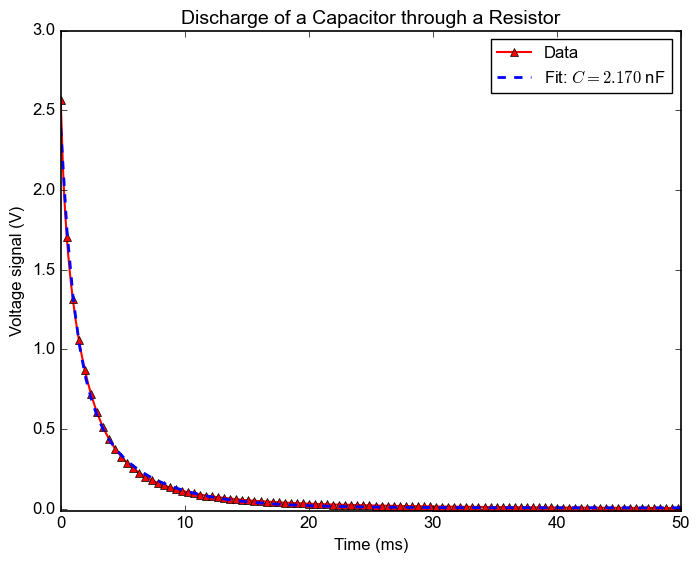

In [36]:
def func(x, a1, b1, a2, b2, c):
    return a1 * np.exp(-x / b1) + a2 * np.exp(-x / b2) + c


mask = np.isfinite(t) & np.isfinite(V2) & (t >= 0.00) & (t <= 0.09)


# Provide sensible initial guesses (p0) for the double-exponential fit
if np.any(mask):
    amp_range = np.max(V2[mask]) - np.min(V2[mask])
    a1_guess = 0.6 * amp_range
    a2_guess = 0.4 * amp_range
    b1_guess = 2e-3  # ~ a few ms
    b2_guess = 2e-2  # ~ few tens of ms
    c0 = np.min(V2[mask])
else:
    amp_range = np.max(V2) - np.min(V2)
    a1_guess = 0.6 * amp_range
    a2_guess = 0.4 * amp_range
    b1_guess = 2e-3
    b2_guess = 2e-2
    c0 = np.min(V2)
p0 = [a1_guess, b1_guess, a2_guess, b2_guess, c0]

popt, pcov = curve_fit(func, t[mask], V2[mask], p0=p0, maxfev=10000)
sigma_fit = func(t[mask], *popt)
a1, b1, a2, b2, c = popt

# Coefficient of determination
ss_res = np.sum((V2[mask] - sigma_fit) ** 2)
ss_tot = np.sum((V2[mask] - np.mean(V2[mask])) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a1_err, b1_err, a2_err, b2_err, c_err = perr


print(f"a1 = {a1:.3g} ± {a1_err:.3g}")
print(f"b1 = {b1:.3g} ± {b1_err:.3g}")
print(f"a2 = {a2:.3g} ± {a2_err:.3g}")
print(f"b2 = {b2:.3g} ± {b2_err:.3g}")
print(f"c = {c:.3g} ± {c_err:.3g}")
print(f"R^2 = {r2:.3f}")



x = np.linspace(0.00, 0.05, 100)
plt.plot(t*1e3, V2, '^', label='Data', color='red', markersize=6, ls='-', lw = 1.5, markevery=50)
plt.plot(x*1e3, func(x, *popt), lw=2, label=rf'Fit: $C={C*1e9:.3f}$ nF', color='blue', linestyle='--')
plt.xlabel(r"Time (ms)")
plt.ylabel(r"Voltage signal (V)")
plt.xlim(0.00, 50)
plt.ylim(-0.01, 3)
plt.legend(frameon=True, loc='upper right', numpoints=1, fontsize=12)
plt.title("Discharge of a Capacitor through a Resistor", fontsize=14)
# plt.savefig("conductance_PS9.eps", format='eps', bbox_inches='tight')
plt.show()